# PPO Training Analysis (IPython)

Run these cells sequentially to inspect training metrics and view each plot inline.

In [31]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
from analyze_training import TrainingAnalyzer

In [32]:
def get_latest_results_dir(base_dir=Path("./results")):
    if not base_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {base_dir}")
    training_dirs = sorted(base_dir.glob("ppo_training_*"))
    if not training_dirs:
        raise FileNotFoundError(f"No training results found in {base_dir}")
    return training_dirs[-1]

def display_plot(plotter, figsize=(8, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    plotter(ax)
    plt.tight_layout()
    plt.show()

In [33]:
results_dir = get_latest_results_dir()
print(f"Using latest training: {results_dir.name}")
analyzer = TrainingAnalyzer(results_dir)

Using latest training: ppo_training_20260427_134246

Training Analyzer Initialized
Results directory: results\ppo_training_20260427_134246
Total episodes: 12000
Total updates: 2231



In [34]:
analyzer.print_summary()
analyzer.compare_phases()


TRAINING SUMMARY

[Configuration]
  num_elements        : 8
  num_interferers     : 1
  angle_threshold     : 10.0
  penalty_reward      : -10.0
  pd_threshold        : -5.0
  eta_rl              : -15.0
  gamma               : 0.99
  lambda_gae          : 0.95
  clip_range          : 0.3
  learning_rate       : 0.0003
  buffer_size         : 2048
  batch_size          : 128

[Training Statistics]
  Total episodes           : 12000
  Total steps              : 6000000
  Stored steps             : 4569934 (76.2%)
  Skipped steps            : 1430066 (23.8%)
  Total updates            : 2231

[Episode Performance]
  Mean reward (all)        : 3876.64 ± 1964.84
  Mean reward (last 100)   : 5881.54
  Mean SIR (all)           : 17.29 ± 3.12 dB
  Mean SIR (last 100)      : 19.85 dB
  Best episode reward      : 6499.16
  Best episode SIR         : 20.57 dB
  Worst episode SIR        : -0.84 dB

[Update Performance (Stored Transitions)]
  Mean update reward       : 20845.66 ± 10484.20
  Mean 

In [35]:
plotters = {
    'Episode Rewards': analyzer._plot_episode_rewards,
    'Episode SIRs': analyzer._plot_episode_sirs,
    'Update Rewards': analyzer._plot_update_rewards,
    'Update SIRs': analyzer._plot_update_sirs,
    'Actor Loss': analyzer._plot_actor_loss,
    'Critic Loss': analyzer._plot_critic_loss,
    'KL Divergence': analyzer._plot_kl_divergence,
    'Training Efficiency': analyzer._plot_training_efficiency,
    'Reward Distribution': analyzer._plot_reward_distribution,
    'SIR Distribution': analyzer._plot_sir_distribution,
    'Rolling Statistics': analyzer._plot_rolling_statistics,
    'Learning Progress': analyzer._plot_learning_progress,
}

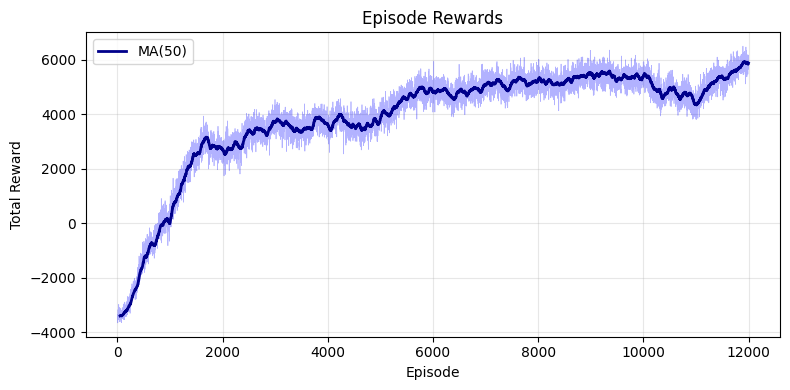

In [36]:
display_plot(plotters['Episode Rewards'])

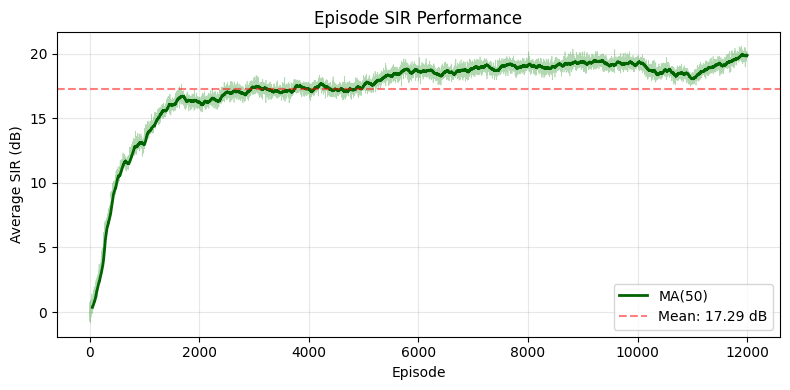

In [37]:
display_plot(plotters['Episode SIRs'])

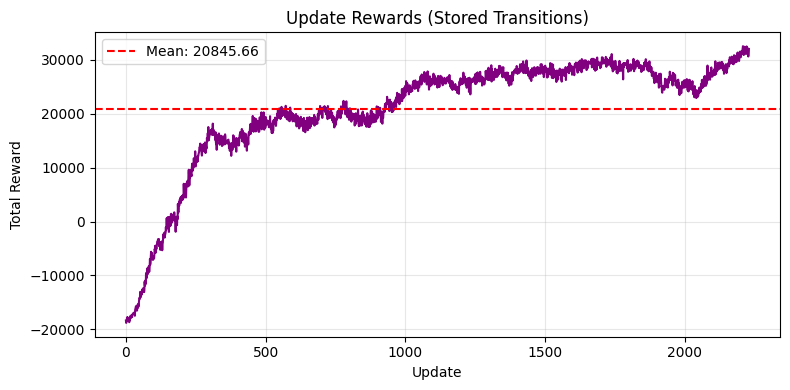

In [38]:
display_plot(plotters['Update Rewards'])

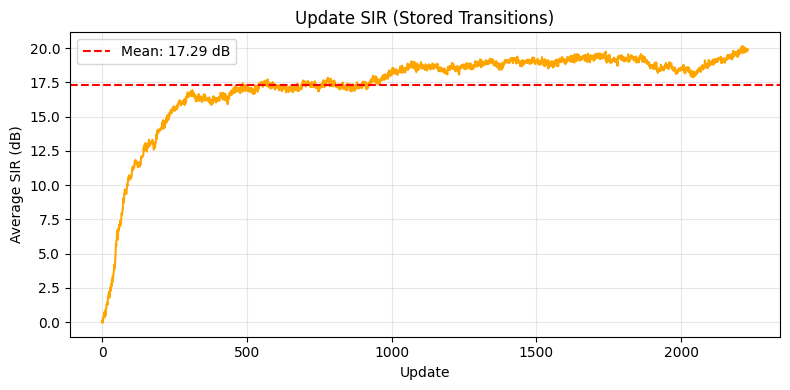

In [39]:
display_plot(plotters['Update SIRs'])

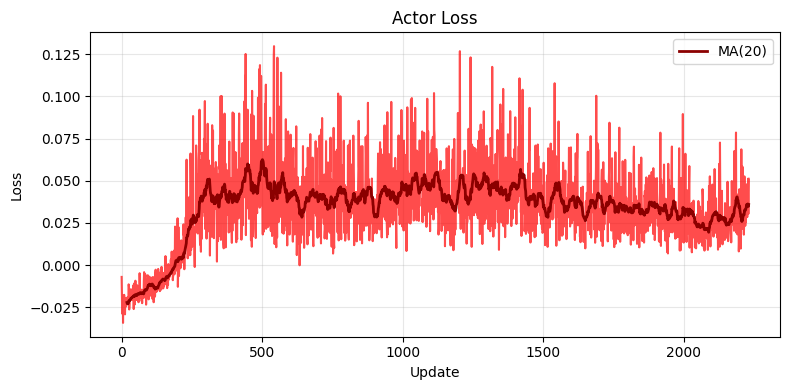

In [40]:
display_plot(plotters['Actor Loss'])

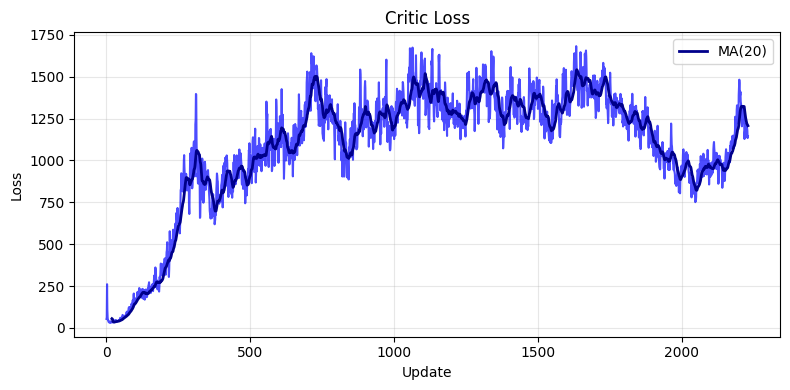

In [41]:
display_plot(plotters['Critic Loss'])

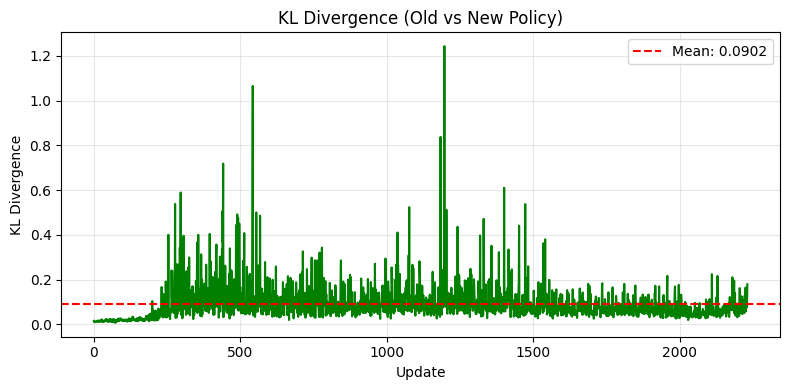

In [42]:
display_plot(plotters['KL Divergence'])

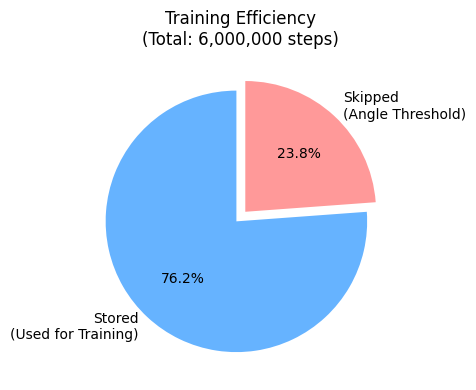

In [43]:
display_plot(plotters['Training Efficiency'])

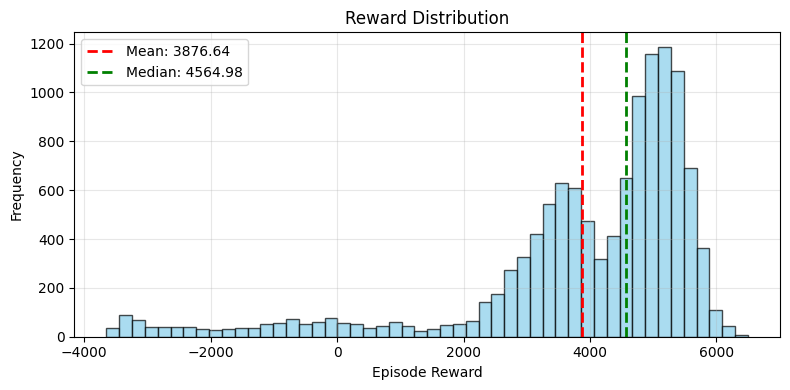

In [44]:
display_plot(plotters['Reward Distribution'])

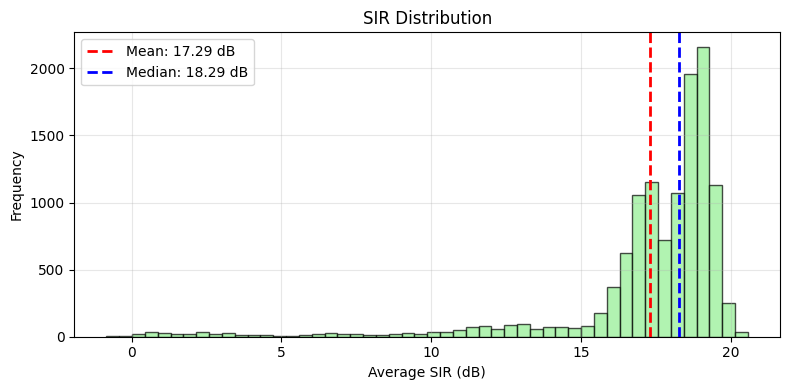

In [45]:
display_plot(plotters['SIR Distribution'])

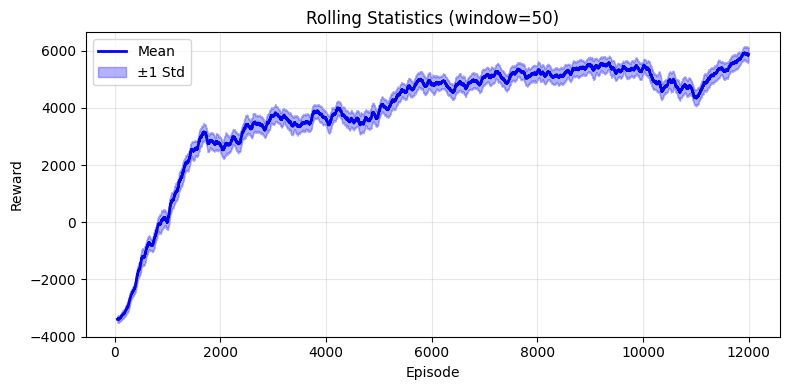

In [46]:
display_plot(plotters['Rolling Statistics'])

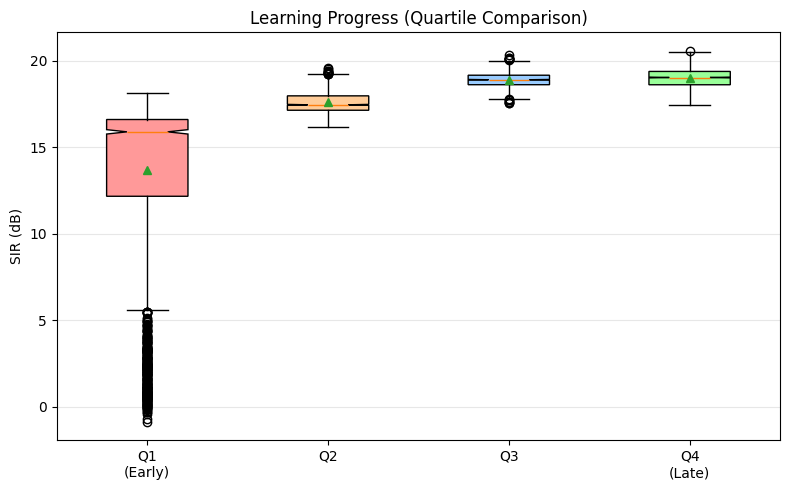

In [47]:
display_plot(plotters['Learning Progress'], figsize=(8, 5))